## Dataset Description
This dataset contains house sale prices for King County, which includes Seattle. It includes 14,620 observations with 23 features. Key variables include 'Price' (target), 'living area', 'number of bedrooms', 'Built Year', and 'grade of the house' (construction quality).

## Analysis Objective
The primary objective of this analysis is to build a supervised learning regression model that accurately predicts the sale price of a house based on its features. We aim to identify which features are the most significant predictors of value.

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score,RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

import joblib

## Data Loading & Initial Exploration

In [2]:
df = pd.read_csv('data.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  - {col}')

Dataset shape: (14620, 23)

Column names:
  - id
  - Date
  - number of bedrooms
  - number of bathrooms
  - living area
  - lot area
  - number of floors
  - waterfront present
  - number of views
  - condition of the house
  - grade of the house
  - Area of the house(excluding basement)
  - Area of the basement
  - Built Year
  - Renovation Year
  - Postal Code
  - Lattitude
  - Longitude
  - living_area_renov
  - lot_area_renov
  - Number of schools nearby
  - Distance from the airport
  - Price


In [3]:
df.head()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [5]:
df.describe()

,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,...,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,42604.538646,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,...,1970.926402,90.924008,122033.062244,52.792848,-114.404007,1996.702257,12753.500068,2.012244,64.950958,5.389322e+05
std,6.237575e+03,67.347991,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,...,29.493625,416.216661,19.082418,0.137522,0.141326,691.093366,26058.414467,0.817284,8.936008,3.675324e+05
min,6.762810e+09,42491.000000,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,1900.000000,0.000000,122003.000000,52.385900,-114.709000,460.000000,651.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,42546.000000,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,...,1951.000000,0.000000,122017.000000,52.707600,-114.519000,1490.000000,5097.750000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,42600.000000,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,...,1975.000000,0.000000,122032.000000,52.806400,-114.421000,1850.000000,7620.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,42662.000000,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,...,1997.000000,0.000000,122048.000000,52.908900,-114.315000,2380.000000,10125.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,42734.000000,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,...,2015.000000,2015.000000,122072.000000,53.007600,-113.505000,6110.000000,560617.000000,3.000000,80.000000,7.700000e+06


In [6]:
df.isna().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

## Exploratory Data Analysis (EDA)

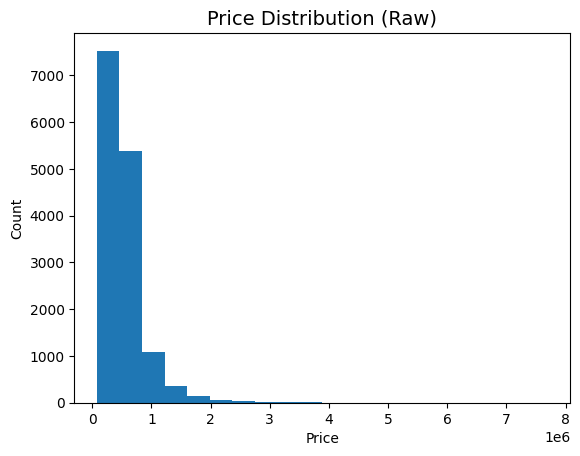

In [7]:
plt.hist(df['Price'], bins=20)
plt.title('Price Distribution (Raw)', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

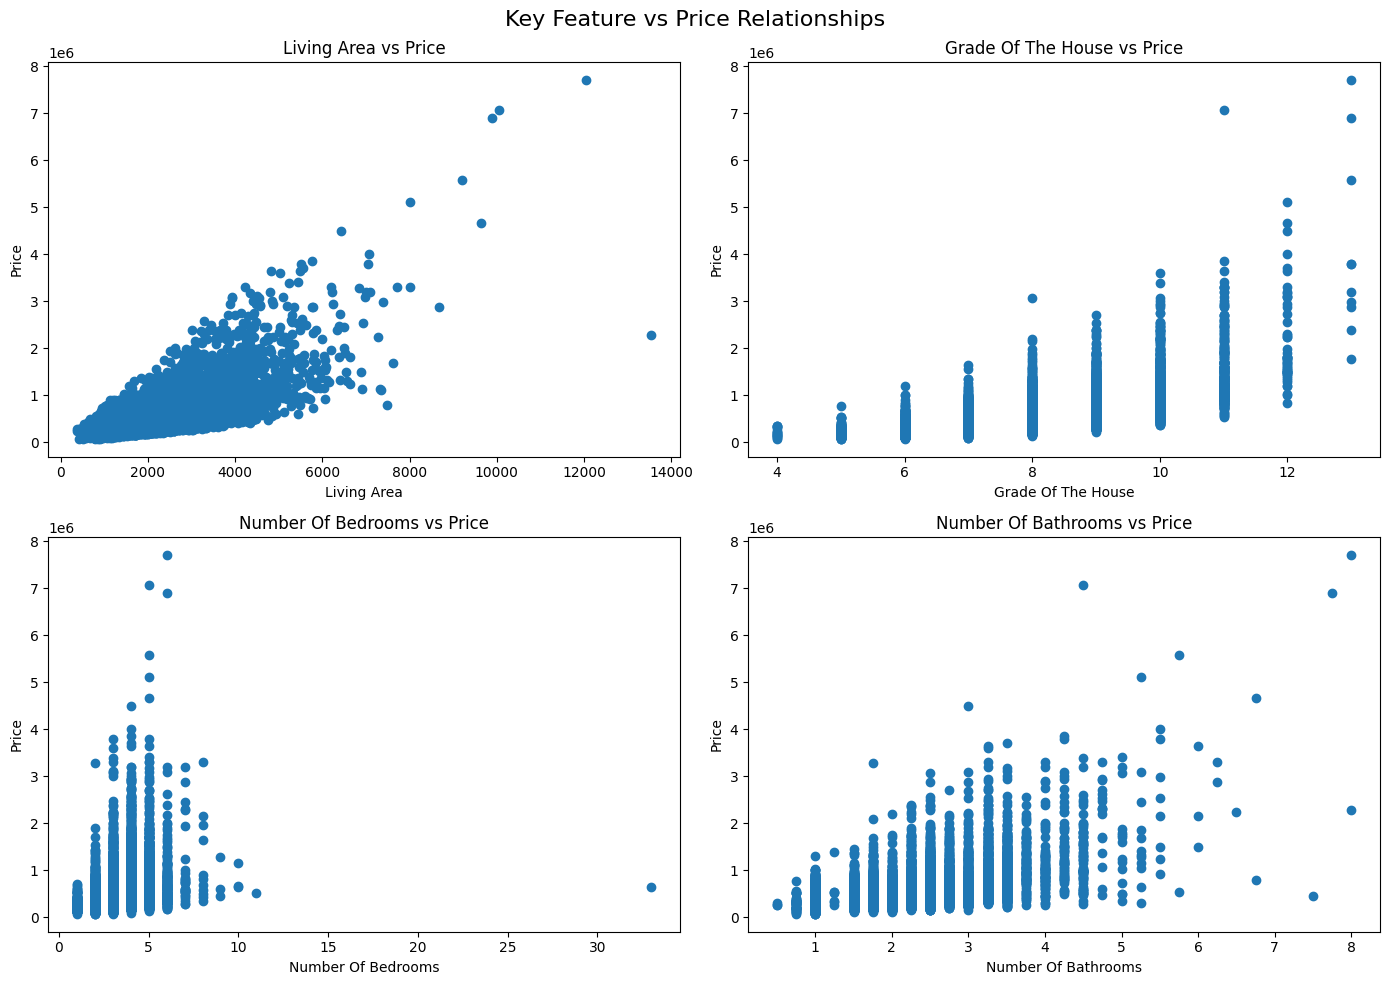

In [8]:
key_features = ['living area', 'grade of the house', 'number of bedrooms', 'number of bathrooms']
length=len(key_features)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()   # convert 2D array to 1D

for i in range(length):
    axes[i].scatter(df[key_features[i]],df["Price"])
    axes[i].set_xlabel(key_features[i].title())
    axes[i].set_ylabel("Price")
    axes[i].set_title(f"{key_features[i].title()} vs Price")

plt.suptitle('Key Feature vs Price Relationships', fontsize=16)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [9]:
df["old"] = 2026-df["Built Year"]
df = df.drop(["id","Date","Lattitude","Longitude","Built Year","Postal Code","condition of the house","grade of the house"], axis=1)
df.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,Area of the house(excluding basement),Area of the basement,Renovation Year,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price,old
0,5,2.50,3650,9050,2.0,0,4,3370,280,0,2880,5400,2,58,2380000,105
1,4,2.50,2920,4000,1.5,0,0,1910,1010,0,2470,4000,2,51,1400000,117
2,5,2.75,2910,9480,1.5,0,0,2910,0,0,2940,6600,1,53,1200000,87
3,4,2.50,3310,42998,2.0,0,0,3310,0,0,3350,42847,3,76,838000,25
4,3,2.00,2710,4500,1.5,0,0,1880,830,0,2060,4500,1,51,805000,97


## Model Training

In [10]:
x=df.drop(["Price"],axis="columns")
x.head()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,Area of the house(excluding basement),Area of the basement,Renovation Year,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,old
0,5,2.50,3650,9050,2.0,0,4,3370,280,0,2880,5400,2,58,105
1,4,2.50,2920,4000,1.5,0,0,1910,1010,0,2470,4000,2,51,117
2,5,2.75,2910,9480,1.5,0,0,2910,0,0,2940,6600,1,53,87
3,4,2.50,3310,42998,2.0,0,0,3310,0,0,3350,42847,3,76,25
4,3,2.00,2710,4500,1.5,0,0,1880,830,0,2060,4500,1,51,97


In [11]:
y=df["Price"]
y.head()

0    2380000
1    1400000
2    1200000
3     838000
4     805000
Name: Price, dtype: int64

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

## Model Comparison & Justification
In this analysis, I compared a standard Linear Regression model with a Random Forest Regressor. The Random Forest model significantly outperformed the Linear Regression model in terms of the R-squared score. I chose to proceed with the Random Forest model because it can capture non-linear relationships and interactions between features (like how 'grade' and 'living area' together impact price) much better than a simple linear model.

In [14]:
def find_best_regression_model(x_train, y_train, cv=5):
    
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(),
        "Lasso": Lasso(),
        "RandomForest": RandomForestRegressor(),
    }
    
    results = {}

    for name, model in models.items():
        scores = cross_val_score(model, x_train, y_train, cv=cv)
        results[name] = np.mean(scores)
        print(f"{name} : {results[name]}")

    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]

    best_model.fit(x_train, y_train)

    return best_model_name, best_model

In [ ]:
name,model=find_best_regression_model(x_train,y_train)
print("Best Model Is ", name)

LinearRegression : 0.6116993690467574
Ridge : 0.6117010600129399


C:\Users\DEV\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.821e+13, tolerance: 1.289e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\DEV\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.088e+13, tolerance: 1.248e+11
  model = cd_fast.enet_coordinate_descent(
C:\Users\DEV\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

Lasso : 0.6116993001495439
RandomForest : 0.6916503771832477
Best Model Is  RandomForest


## Model Comparison & Justification
In this analysis, I compared a standard Linear Regression model with a Random Forest Regressor. The Random Forest model significantly outperformed the Linear Regression model in terms of the R-squared score. I chose to proceed with the Random Forest model because it can capture non-linear relationships and interactions between features (like how 'grade' and 'living area' together impact price) much better than a simple linear model.

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, 
                               n_iter=10, cv=3, random_state=42, n_jobs=-1)

rf_random.fit(x_train, y_train)
model = rf_random.best_estimator_

In [17]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [18]:
model.score(x_test,y_test)

0.7162349062556728

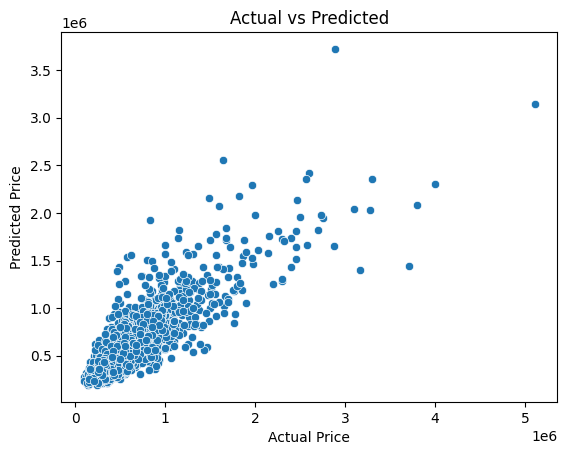

In [19]:
sns.scatterplot(x=y_test, y=model.predict(x_test))
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

## Findings & Interpretation
The "Actual vs Predicted" scatter plot shows that the model follows the 45-degree line closely for the majority of houses, indicating high accuracy. Most of the error occurs at the higher end of the price spectrum, where the model tends to under-predict the value of luxury estates.

In [20]:
joblib.dump(model,"model.joblib")

['model.joblib']

In [21]:
model.predict([[5,2.50,3650,9050,2.0,0,4,3370,280,0,2880,5400,2,58,105]])

array([4057585.])